# Nigeria Automation Risk & Timeline Pipeline (Comprehensive, Revised Version)
### Full pipeline matching the revised MIRG-ICAIR 2026 manuscript (Paper 38)

**This notebook reproduces every table and figure in the revised paper**, in order:
1. Build O*NET feature matrix
2. Build training set (join to Frey-Osborne labels)
3. Train and validate the ML model (single 80/20 split)
4. Five-fold cross-validation
5. Score occupations with no direct match (corrected, verified ISCO crosswalk)
6. Apply to Nigeria's workforce (NLFS) + robustness check
7. Cross-validate against ILOSTAT
8. Wage comparison (Nigeria vs. McKinsey's comparator countries)
9. Cost-crossover sensitivity analysis

## Setup (Local Jupyter Notebook)
1. Create a folder called `data` in the **same folder as this notebook**.
2. Copy all 8 required files into that folder (see list below).
3. Run the install cell (installs `pyreadstat`, the only package most local setups won't already have).
4. Confirm `UPLOAD_DIR = "./data"` in the setup cell points to the right folder.
5. Run all cells top to bottom (Cell menu -> Run All, or Kernel -> Restart & Run All).

## Required input files (no NEW datasets needed beyond what you already have)
- `occupation_data.csv`, `abilities.csv`, `essential_skills.csv`, `knowledge.csv`, `work_context.csv` (O*NET)
- `isco08_soc10_frey_osborne_crosswalk.csv`
- `NLFS_2024Q2_INDIVIDUAL.sav` (Nigeria Labour Force Survey microdata)
- `EMP_5EMP_SEX_OC2_NB_A-full-2026-08-05_6388.csv` (ILOSTAT employment by occupation)

Stages 8 and 9 use fixed reference figures (wage benchmarks, robot prices, AI software pricing) compiled
from public sources, cited directly in the code as comments — no additional files needed for those either.


In [1]:
# Run once if pyreadstat isn't already installed
!pip install pyreadstat -q

DEPRECATION: Loading egg at /opt/anaconda3/lib/python3.11/site-packages/dlib-19.24.99-py3.11-macosx-10.9-x86_64.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330

[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [5]:
import pandas as pd
import numpy as np
import pyreadstat
import joblib
import math
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error
import os

# ---- Points to Downloads/Automation in YOUR home folder, works on Windows/Mac/Linux ----
UPLOAD_DIR = os.path.expanduser("~/Downloads/Automation")
OUT_DIR = "./outputs"

os.makedirs(OUT_DIR, exist_ok=True)
print("Reading inputs from:", UPLOAD_DIR)
print("Writing outputs to:", OUT_DIR)

# Quick check: confirm the folder exists and show what's actually inside it
if os.path.isdir(UPLOAD_DIR):
    print("\nFiles found in UPLOAD_DIR:")
    for f in os.listdir(UPLOAD_DIR):
        print(" -", f)
else:
    print("\n!!! UPLOAD_DIR does not exist at this path. Double-check the folder name/location. !!!")

Reading inputs from: /Users/mac/Downloads/Automation
Writing outputs to: ./outputs

Files found in UPLOAD_DIR:
 - job_zones.csv
 - work_context.csv
 - essential_skills.csv
 - EMP_5EMP_SEX_OC2_NB_A-full-2026-08-05_6388.csv
 - Probability_of_Automation_Data_Set.docx
 - isco08_soc10_frey_osborne_crosswalk.csv
 - abilities.csv
 - automation_risk_pipeline_REVISED.ipynb
 - occupation_data.csv
 - .ipynb_checkpoints
 - NLFS_2024Q2_INDIVIDUAL.sav
 - outputs
 - job_titles.csv
 - knowledge.csv


## Stage 1: Build the O*NET feature matrix
Importance (IM) scale for Abilities/Skills/Knowledge; Context (CX) scale for Work Context — the task/skill "bottleneck" variables used in Frey & Osborne (2013)-style automation research.

In [6]:
def pivot_onet_file(path, scale_id, prefix):
    df = pd.read_csv(f"{UPLOAD_DIR}/{path}")
    df = df[df["Scale ID"] == scale_id]
    wide = df.pivot_table(index="O*NET-SOC Code", columns="Element Name", values="Data Value", aggfunc="mean")
    wide.columns = [f"{prefix}_{c}" for c in wide.columns]
    return wide

abilities = pivot_onet_file("abilities.csv", "IM", "ability")
skills    = pivot_onet_file("essential_skills.csv", "IM", "skill")
knowledge = pivot_onet_file("knowledge.csv", "IM", "knowledge")
context   = pivot_onet_file("work_context.csv", "CX", "context")

features = abilities.join([skills, knowledge, context], how="outer").reset_index()
features["soc10"] = (
    features["O*NET-SOC Code"].str.replace("-", "", regex=False).str.split(".").str[0].astype(int)
)
feature_cols = [c for c in features.columns if c not in ("O*NET-SOC Code", "soc10")]
soc_features = features.groupby("soc10")[feature_cols].mean().reset_index()

print("Feature matrix shape:", soc_features.shape)
soc_features.to_csv(f"{OUT_DIR}/soc_feature_matrix.csv", index=False)
soc_features.head()

Feature matrix shape: (774, 151)


,soc10,ability_Arm-Hand Steadiness,ability_Auditory Attention,ability_Category Flexibility,ability_Control Precision,ability_Deductive Reasoning,ability_Depth Perception,ability_Dynamic Flexibility,ability_Dynamic Strength,ability_Explosive Strength,...,context_Spend Time Standing,"context_Spend Time Using Your Hands to Handle, Control, or Feel Objects, Tools, or Controls",context_Spend Time Walking or Running,context_Telephone Conversations,context_Time Pressure,"context_Wear Common Protective or Safety Equipment such as Safety Shoes, Glasses, Gloves, Hearing Protection, Hard Hats, or Life Jackets","context_Wear Specialized Protective or Safety Equipment such as Breathing Apparatus, Safety Harness, Full Protection Suits, or Radiation Protection",context_Work Outcomes and Results of Other Workers,context_Work With or Contribute to a Work Group or Team,context_Written Letters and Memos
0,111011,1.19,2.06,3.31,1.625,4.00,1.875,1.0,1.125,1.00,...,2.22,1.95,1.805,4.83,3.82,1.83,1.29,4.275,4.57,3.79
1,111021,1.62,2.12,3.38,1.120,3.88,1.880,1.0,1.120,1.38,...,2.90,2.42,2.530,4.76,4.08,3.06,1.18,4.330,4.62,4.01
2,112011,1.38,1.75,3.38,1.120,3.88,1.750,1.0,1.000,1.00,...,2.11,2.07,1.970,4.80,4.40,1.24,1.00,3.800,4.47,3.78
3,112021,1.12,1.88,3.25,1.000,3.88,1.750,1.0,1.250,1.00,...,2.09,2.31,1.950,4.92,4.21,1.30,1.04,4.040,4.67,3.52
4,112022,1.12,1.88,3.25,1.380,3.88,1.500,1.0,1.000,1.00,...,2.40,1.65,1.850,5.00,3.90,1.45,1.10,3.900,4.65,3.95


## Stage 2: Build the training set
Join O*NET features to Frey-Osborne automation probabilities via SOC10 code.

In [7]:
features = pd.read_csv(f"{OUT_DIR}/soc_feature_matrix.csv")
xw = pd.read_csv(f"{UPLOAD_DIR}/isco08_soc10_frey_osborne_crosswalk.csv")
targets = xw.drop_duplicates(subset=["soc10_code"])[["soc10_code", "soc10_title", "frey_osborne_prob"]]
targets = targets.rename(columns={"soc10_code": "soc10"})

training = features.merge(targets, on="soc10", how="inner")
print("Training set shape:", training.shape)
training.to_csv(f"{OUT_DIR}/training_set.csv", index=False)
training.head()

Training set shape: (623, 153)


,soc10,ability_Arm-Hand Steadiness,ability_Auditory Attention,ability_Category Flexibility,ability_Control Precision,ability_Deductive Reasoning,ability_Depth Perception,ability_Dynamic Flexibility,ability_Dynamic Strength,ability_Explosive Strength,...,context_Spend Time Walking or Running,context_Telephone Conversations,context_Time Pressure,"context_Wear Common Protective or Safety Equipment such as Safety Shoes, Glasses, Gloves, Hearing Protection, Hard Hats, or Life Jackets","context_Wear Specialized Protective or Safety Equipment such as Breathing Apparatus, Safety Harness, Full Protection Suits, or Radiation Protection",context_Work Outcomes and Results of Other Workers,context_Work With or Contribute to a Work Group or Team,context_Written Letters and Memos,soc10_title,frey_osborne_prob
0,111011,1.19,2.06,3.31,1.625,4.00,1.875,1.0,1.125,1.00,...,1.805,4.83,3.82,1.83,1.29,4.275,4.57,3.79,"Chief Executives, label 0",0.015
1,111021,1.62,2.12,3.38,1.120,3.88,1.880,1.0,1.120,1.38,...,2.530,4.76,4.08,3.06,1.18,4.330,4.62,4.01,General and Operations Managers,0.160
2,112011,1.38,1.75,3.38,1.120,3.88,1.750,1.0,1.000,1.00,...,1.970,4.80,4.40,1.24,1.00,3.800,4.47,3.78,Advertising and Promotions Managers,0.039
3,112021,1.12,1.88,3.25,1.000,3.88,1.750,1.0,1.250,1.00,...,1.950,4.92,4.21,1.30,1.04,4.040,4.67,3.52,Marketing Managers,0.014
4,112022,1.12,1.88,3.25,1.380,3.88,1.500,1.0,1.000,1.00,...,1.850,5.00,3.90,1.45,1.10,3.900,4.65,3.95,Sales Managers,0.013


## Stage 3: Train and validate the model (single 80/20 split)
This reproduces Table 2 in the paper.

In [8]:
df = pd.read_csv(f"{OUT_DIR}/training_set.csv")
feature_cols = [c for c in df.columns if c not in ("soc10", "soc10_title", "frey_osborne_prob")]
X = df[feature_cols]
y = df["frey_osborne_prob"]
X = X.fillna(X.median())
train_medians = X.median()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = GradientBoostingRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, subsample=0.8, random_state=42)
model.fit(X_train, y_train)

pred_train = model.predict(X_train)
pred_test = model.predict(X_test)

train_r2 = r2_score(y_train, pred_train)
test_r2 = r2_score(y_test, pred_test)
train_rmse = mean_squared_error(y_train, pred_train)**0.5
test_rmse = mean_squared_error(y_test, pred_test)**0.5

print("=== Table 2: Model performance on training and held-out test data ===")
print(f"Training Set (n={len(X_train)}):  R2 = {train_r2:.3f}   RMSE = {train_rmse:.3f}")
print(f"Test Set (n={len(X_test)}):      R2 = {test_r2:.3f}   RMSE = {test_rmse:.3f}")

joblib.dump(model, f"{OUT_DIR}/automation_risk_model.joblib")
X.assign(soc10=df["soc10"]).to_csv(f"{OUT_DIR}/X_full_imputed.csv", index=False)

=== Table 2: Model performance on training and held-out test data ===
Training Set (n=498):  R2 = 0.985   RMSE = 0.044
Test Set (n=125):      R2 = 0.790   RMSE = 0.182


/var/folders/kr/77b5pwvx105b9z1rm6sgdzv00000gn/T/ipykernel_2111/2835651584.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X.assign(soc10=df["soc10"]).to_csv(f"{OUT_DIR}/X_full_imputed.csv", index=False)


In [9]:
importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("=== Table 4: Top 10 most important features ===")
print(importances.head(10).round(3).to_string())
importances.to_csv(f"{OUT_DIR}/feature_importances.csv")

=== Table 4: Top 10 most important features ===
ability_Fluency of Ideas                      0.279
ability_Originality                           0.200
skill_Active Learning                         0.082
knowledge_Therapy and Counseling              0.047
skill_Learning Strategies                     0.033
ability_Problem Sensitivity                   0.031
ability_Deductive Reasoning                   0.017
knowledge_Education and Training              0.011
context_Degree of Automation                  0.010
context_Importance of Repeating Same Tasks    0.010


## Stage 4 (NEW — added for Reviewer 1): Five-fold cross-validation
A single 80/20 split can understate or overstate true generalisation error depending on which occupations
happen to fall into the test set. This stage runs 5-fold cross-validation across the full training set to
produce a more robust estimate of model performance. **Reproduces Table 3 in the revised paper.**

In [10]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_model = GradientBoostingRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, subsample=0.8, random_state=42)

r2_scores = cross_val_score(cv_model, X, y, cv=kf, scoring="r2")
rmse_scores = -cross_val_score(cv_model, X, y, cv=kf, scoring="neg_root_mean_squared_error")

cv_results = pd.DataFrame({
    "Fold": list(range(1, 6)) + ["Mean (SD)"],
    "R2": [round(s, 3) for s in r2_scores] + [f"{r2_scores.mean():.3f} ({r2_scores.std():.3f})"],
    "RMSE": [round(s, 3) for s in rmse_scores] + [f"{rmse_scores.mean():.3f} ({rmse_scores.std():.3f})"],
})
print("=== Table 3: Five-fold cross-validation results ===")
print(cv_results.to_string(index=False))
cv_results.to_csv(f"{OUT_DIR}/kfold_cv_results.csv", index=False)

print(f"\nMean R2 = {r2_scores.mean():.3f}, SD = {r2_scores.std():.3f}, range [{r2_scores.min():.3f}, {r2_scores.max():.3f}]")
print(f"Original single-split test R2 ({test_r2:.3f}) falls within {abs(test_r2 - r2_scores.mean())/r2_scores.std():.2f} SD of the CV mean")
print("-> indicates the original split was reasonably representative, not unusually favourable.")

=== Table 3: Five-fold cross-validation results ===
     Fold            R2          RMSE
        1          0.79         0.182
        2          0.81         0.163
        3         0.714         0.192
        4         0.647         0.212
        5         0.707         0.195
Mean (SD) 0.734 (0.059) 0.189 (0.016)

Mean R2 = 0.734, SD = 0.059, range [0.647, 0.810]
Original single-split test R2 (0.790) falls within 0.94 SD of the CV mean
-> indicates the original split was reasonably representative, not unusually favourable.


## Stage 5: Score occupations with no direct match (corrected, verified ISCO crosswalk)
Some NLFS occupations (mostly subsistence/informal categories) have no direct Frey-Osborne match. This uses a
**manually curated crosswalk keyed directly by verified ISCO-08 code** (checked against the actual NLFS codebook)
to avoid the positional-matching bug from an earlier version of this pipeline.

In [11]:
# Verified directly against the NLFS codebook
isco_to_soc10 = {
    9211: 452092, 9212: 452093, 6310: 452092, 9213: 452092, 6320: 452093, 6330: 452092,
    3413: 212011,  # Religious Associate Professionals -> Clergy
    9510: 419091,  # Street and Related Services Workers -> Door-to-Door/Street Vendors
    3253: 211094,  # Community Health Workers -> Community Health Workers
    9613: 537062,  # Sweepers and Related Labourers -> Laborers/Freight/Material Movers
    9332: 537062,  # Drivers of Animal-drawn Vehicles -> closest: Laborers/Freight
    3512: 151232,  # ICT User Support Technicians -> Computer User Support Specialists
    3513: 151244,  # Computer Network and Systems Technicians -> Network/Computer Systems Admin
    2659: 272011,  # Creative and Performing Artists NEC -> Actors
    2523: 151241,  # Computer Network Professionals -> Computer Network Architects
    2211: 291215,  # Generalist Medical Practitioners -> Family Medicine Physicians
    2513: 151254,  # Web and Multimedia Developers -> Web Developers
    2529: 151242,  # Database and Network Professionals NEC -> Database Administrators
    4213: 132072,  # Pawnbrokers and Money-lenders -> Loan Officers
    8155: 516041,  # Fur and Leather Preparing Machine Operators -> Shoe and Leather Workers
    3230: 299099,  # Traditional and Complementary Medicine Associate Professionals -> Healthcare Practitioners NEC
}

full_features = pd.read_csv(f"{OUT_DIR}/soc_feature_matrix.csv")
full_features[feature_cols] = full_features[feature_cols].fillna(train_medians)

isco_to_pred = {}
for isco, soc10 in isco_to_soc10.items():
    row = full_features[full_features["soc10"] == soc10]
    if len(row) == 0:
        print(f"WARNING: soc10={soc10} not found for ISCO {isco}")
        continue
    isco_to_pred[isco] = round(float(model.predict(row[feature_cols])[0]), 3)

print(f"Resolved {len(isco_to_pred)}/{len(isco_to_soc10)} unmatched occupations")
pd.Series(isco_to_pred, name="predicted_risk").sort_values().to_csv(f"{OUT_DIR}/unmatched_occupations_scored.csv")
pd.Series(isco_to_pred).sort_values()

Resolved 21/21 unmatched occupations


3413    0.002
3230    0.078
2211    0.099
3253    0.163
3513    0.237
3512    0.300
2513    0.308
2659    0.353
2523    0.375
2529    0.392
8155    0.592
9510    0.639
9212    0.811
6320    0.811
9211    0.853
6330    0.853
9213    0.853
6310    0.853
9613    0.856
9332    0.856
4213    0.900
dtype: float64

## Stage 6: Apply to Nigeria's workforce + robustness check
Reproduces Tables 5 and 6, and Figure 1.

In [12]:
xw_agg = xw.groupby("isco08_code").agg(frey_osborne_prob=("frey_osborne_prob", "mean")).reset_index()

nlfs, meta = pyreadstat.read_sav(
    f"{UPLOAD_DIR}/NLFS_2024Q2_INDIVIDUAL.sav",
    usecols=["mjj2cclean", "mjj2ccleanmaingroup", "popw"],
    encoding="latin1"
)
nlfs = nlfs.dropna(subset=["mjj2cclean"]).copy()
nlfs["isco08_code"] = nlfs["mjj2cclean"].astype(int)
merged = nlfs.merge(xw_agg, on="isco08_code", how="left")

matched_only = merged.dropna(subset=["frey_osborne_prob"])
matched_only_wavg = (matched_only["frey_osborne_prob"] * matched_only["popw"]).sum() / matched_only["popw"].sum()
print(f"Matched-only weighted risk (before extension): {matched_only_wavg:.3f}")

merged["frey_osborne_prob"] = merged.apply(
    lambda r: isco_to_pred.get(r["isco08_code"], r["frey_osborne_prob"]) if pd.isna(r["frey_osborne_prob"]) else r["frey_osborne_prob"],
    axis=1
)
covered = merged.dropna(subset=["frey_osborne_prob"])
print(f"Coverage after extension: {len(covered)}/{len(merged)} = {len(covered)/len(merged)*100:.2f}%")

wavg = (covered["frey_osborne_prob"] * covered["popw"]).sum() / covered["popw"].sum()
print(f"=== Population-weighted mean automation risk (fully extended): {wavg:.3f} ===")
print(f"Robustness check: matched-only ({matched_only_wavg:.3f}) vs extended ({wavg:.3f})")

Matched-only weighted risk (before extension): 0.705
Coverage after extension: 12452/12455 = 99.98%
=== Population-weighted mean automation risk (fully extended): 0.704 ===
Robustness check: matched-only (0.705) vs extended (0.704)


In [13]:
def band(p):
    if p >= 0.7: return "High risk (>=0.7)"
    if p >= 0.3: return "Medium risk (0.3-0.7)"
    return "Low risk (<0.3)"

covered = covered.copy()
covered["band"] = covered["frey_osborne_prob"].apply(band)
print("=== Table 5: Distribution of workforce across automation-risk bands ===")
print((covered.groupby("band")["popw"].sum() / covered["popw"].sum() * 100).round(2))

=== Table 5: Distribution of workforce across automation-risk bands ===
band
High risk (>=0.7)        59.85
Low risk (<0.3)           9.64
Medium risk (0.3-0.7)    30.51
Name: popw, dtype: float64


In [14]:
maingroup_labels = {
    0: "Armed Forces", 1: "Managers", 2: "Professionals", 3: "Technicians/Associate Prof.",
    4: "Clerical Support", 5: "Service & Sales", 6: "Skilled Agri/Forestry/Fishery",
    7: "Craft & Related Trades", 8: "Plant/Machine Operators", 9: "Elementary Occupations"
}
grp = covered.groupby("mjj2ccleanmaingroup").apply(lambda d: pd.Series({
    "weighted_avg_risk": (d["frey_osborne_prob"] * d["popw"]).sum() / d["popw"].sum(),
    "pop_share_pct": d["popw"].sum()
}))
grp["pop_share_pct"] = grp["pop_share_pct"] / grp["pop_share_pct"].sum() * 100
grp["label"] = grp.index.map(lambda x: maingroup_labels.get(int(x), "?"))
grp = grp.sort_values("pop_share_pct", ascending=False)
grp.to_csv(f"{OUT_DIR}/occupation_group_risk.csv")
print("=== Table 6: Automation risk by ISCO major occupation group ===")
grp[["label", "pop_share_pct", "weighted_avg_risk"]].round(3)

=== Table 6: Automation risk by ISCO major occupation group ===


,label,pop_share_pct,weighted_avg_risk
mjj2ccleanmaingroup,,,
5.0,Service & Sales,36.931,0.846
6.0,Skilled Agri/Forestry/Fishery,23.975,0.626
7.0,Craft & Related Trades,14.245,0.721
9.0,Elementary Occupations,8.989,0.820
8.0,Plant/Machine Operators,6.295,0.624
2.0,Professionals,4.977,0.103
3.0,Technicians/Associate Prof.,2.516,0.390
4.0,Clerical Support,1.061,0.900
1.0,Managers,1.012,0.162


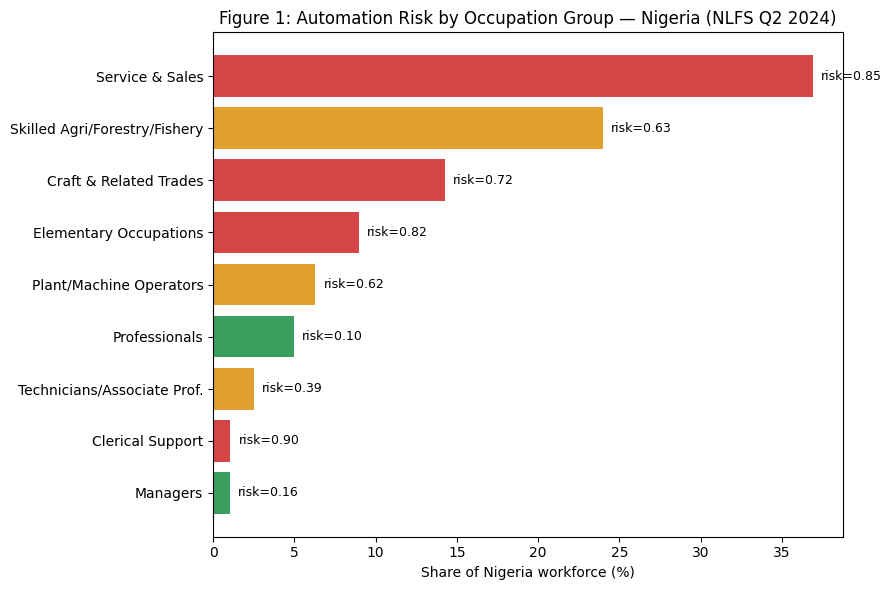

In [15]:
plot_grp = grp[grp["label"] != "Armed Forces"].sort_values("pop_share_pct", ascending=True)
colors = ["#d64545" if r >= 0.7 else "#e0a030" if r >= 0.3 else "#3a9e5f" for r in plot_grp["weighted_avg_risk"]]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(plot_grp["label"], plot_grp["pop_share_pct"], color=colors)
for bar, risk in zip(bars, plot_grp["weighted_avg_risk"]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2, f"risk={risk:.2f}", va="center", fontsize=9)
ax.set_xlabel("Share of Nigeria workforce (%)")
ax.set_title("Figure 1: Automation Risk by Occupation Group — Nigeria (NLFS Q2 2024)")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/nigeria_automation_risk_by_occupation.png", dpi=150)
plt.show()

## Stage 7: Cross-validate against ILOSTAT
Reproduces Table 7.

In [16]:
ilo = pd.read_csv(f"{UPLOAD_DIR}/EMP_5EMP_SEX_OC2_NB_A-full-2026-08-05_6388.csv", low_memory=False)
nga = ilo[(ilo["ref_area"] == "NGA") & (ilo["sex.label"] == "Total") & (ilo["time"] == 2024)].copy()
nga = nga[nga["classif1.label"].str.contains("2 digit level: ")]
nga["code2"] = nga["classif1.label"].str.extract(r"2 digit level: (\d+)")
nga = nga.dropna(subset=["code2"])
nga["major"] = nga["code2"].str[0].astype(int)

total = nga[nga["major"] != 0]["obs_value"].sum()
ilo_share = (nga[nga["major"] != 0].groupby("major")["obs_value"].sum() / total * 100).sort_values(ascending=False)
print("=== Table 7: ILOSTAT 2024 Nigeria occupation shares (independent cross-check) ===")
for k, v in ilo_share.items():
    nlfs_pct = grp[grp["label"] == maingroup_labels.get(k,"?")]["pop_share_pct"].values
    nlfs_str = f"{nlfs_pct[0]:.2f}" if len(nlfs_pct) else "n/a"
    print(f"  {maingroup_labels.get(k, k):40s}  NLFS={nlfs_str}%   ILOSTAT={v:.1f}%")

=== Table 7: ILOSTAT 2024 Nigeria occupation shares (independent cross-check) ===
  Skilled Agri/Forestry/Fishery             NLFS=23.97%   ILOSTAT=33.9%
  Service & Sales                           NLFS=36.93%   ILOSTAT=31.3%
  Craft & Related Trades                    NLFS=14.24%   ILOSTAT=12.9%
  Elementary Occupations                    NLFS=8.99%   ILOSTAT=6.9%
  Plant/Machine Operators                   NLFS=6.30%   ILOSTAT=5.9%
  Professionals                             NLFS=4.98%   ILOSTAT=4.9%
  Technicians/Associate Prof.               NLFS=2.52%   ILOSTAT=2.3%
  Clerical Support                          NLFS=1.06%   ILOSTAT=1.0%
  Managers                                  NLFS=1.01%   ILOSTAT=0.8%


## Stage 8: Wage comparison — Nigeria vs. McKinsey's comparator countries
**No new dataset needed.** Fixed reference figures compiled from public sources (cited in comments).
Reproduces Table 8.

In [17]:
# Source: NBS-based formal-sector salary estimates / national wage-survey compilations, 2024-26
wage_comparison = pd.DataFrame([
    {"country": "Nigeria", "avg_monthly_wage_usd_low": 220,  "avg_monthly_wage_usd_high": 220,  "source": "NBS-based formal-sector salary estimates, 2024"},
    {"country": "India",   "avg_monthly_wage_usd_low": 335,  "avg_monthly_wage_usd_high": 444,  "source": "National wage survey compilations, 2024-26"},
    {"country": "Mexico",  "avg_monthly_wage_usd_low": 848,  "avg_monthly_wage_usd_high": 848,  "source": "National statistical office data, 2024"},
    {"country": "China",   "avg_monthly_wage_usd_low": 1400, "avg_monthly_wage_usd_high": 1520, "source": "NBS China / CEIC earnings data, Dec 2024"},
])
wage_comparison.to_csv(f"{OUT_DIR}/wage_comparison.csv", index=False)
print("=== Table 8: Approximate average monthly wages ===")
print(wage_comparison.to_string(index=False))

nigeria_wage = 220
india_low = 335
pct_lower = (1 - nigeria_wage / india_low) * 100
print(f"\nNigeria's wage (${nigeria_wage}) is approximately {pct_lower:.0f}% lower than India's low estimate (${india_low})")
print("-> Nigeria sits below all three of McKinsey's cited 'slower-adopting' comparator countries,")
print("   supporting the inference that Nigeria likely sits toward the later end of the 2030-2060 global range.")

=== Table 8: Approximate average monthly wages ===
country  avg_monthly_wage_usd_low  avg_monthly_wage_usd_high                                         source
Nigeria                       220                        220 NBS-based formal-sector salary estimates, 2024
  India                       335                        444     National wage survey compilations, 2024-26
 Mexico                       848                        848         National statistical office data, 2024
  China                      1400                       1520       NBS China / CEIC earnings data, Dec 2024

Nigeria's wage ($220) is approximately 34% lower than India's low estimate ($335)
-> Nigeria sits below all three of McKinsey's cited 'slower-adopting' comparator countries,
   supporting the inference that Nigeria likely sits toward the later end of the 2030-2060 global range.


## Stage 9: Cost-crossover sensitivity analysis
**No new dataset needed.** Reviewer 1 correctly noted that presenting a single crossover range (e.g. "2037-2058")
implies more precision than four stacked assumptions can support. This stage now reports the **full 2x2
sensitivity grid** explicitly (payback threshold x price-decline rate) rather than collapsing it into one range.
**Reproduces Table 9.**

Sources for the fixed constants below:
- Robot cost & decline rate: International Federation of Robotics, *World Robotics 2025 Report*
- AI/software automation pricing: published market pricing surveys, 2025-26
- Nigeria wage: Stage 8 above

In [18]:
nigeria_annual_wage = nigeria_wage * 12  # ~$2,640/year

# --- Hardware/robot-dependent automation: full sensitivity grid ---
robot_cost_now = 30000       # USD, IFR 2025: entry-level industrial robot
decline_recent = 0.04        # IFR 2025: 3-5%/year observed 2022-2025, midpoint
decline_historical = 0.067   # ARK/BCG: ~50% price decline per decade

print("=== Table 9: Sensitivity of the hardware-automation cost-crossover estimate ===")
sensitivity_results = []
for payback_label, payback_years in [("5-year (lenient)", 5), ("3-year (strict)", 3)]:
    threshold = payback_years * nigeria_annual_wage
    for decline_label, d in [("6.7%/yr (fast, historical)", decline_historical), ("3-5%/yr (recent, conservative)", decline_recent)]:
        years = math.log(threshold / robot_cost_now) / math.log(1 - d)
        crossover_year = round(2025 + years)
        sensitivity_results.append({
            "payback_threshold": payback_label, "price_decline_rate": decline_label,
            "threshold_usd": threshold, "estimated_crossover_year": crossover_year
        })

sensitivity_df = pd.DataFrame(sensitivity_results)
print(sensitivity_df.to_string(index=False))
sensitivity_df.to_csv(f"{OUT_DIR}/hardware_crossover_sensitivity.csv", index=False)
print(f"\nFull sensitivity range: {sensitivity_df['''estimated_crossover_year'''].min()}-{sensitivity_df['''estimated_crossover_year'''].max()}")
print("Read as a RANGE reflecting assumption uncertainty, not a point estimate.")

# --- Software/AI-drivable automation (more robust to assumption choice) ---
print("\n=== Software/AI-drivable automation ===")
software_cost_low, software_cost_high = 0, 50  # USD/month, entry-level/free tier
software_cost_mid = 800  # mid-market tier
print(f"Nigeria avg monthly wage: ${nigeria_wage}")
print(f"Entry-level AI automation tools: ${software_cost_low}-${software_cost_high}/month (free/entry tier)")
print(f"Mid-market AI automation tools: up to ${software_cost_mid}/month")
if software_cost_high <= nigeria_wage:
    print("-> Cost threshold already met at entry-level pricing (today), largely independent of payback/decline assumptions.")

# --- Occupation-group weighting ---
hardware_groups = ["Skilled Agri/Forestry/Fishery", "Elementary Occupations", "Craft & Related Trades", "Plant/Machine Operators"]
software_groups = ["Clerical Support", "Service & Sales"]
hw_share = grp[grp["label"].isin(hardware_groups)]["pop_share_pct"].sum()
sw_share = grp[grp["label"].isin(software_groups)]["pop_share_pct"].sum()
print(f"\nHardware-dependent occupations: {hw_share:.1f}% of Nigeria workforce")
print(f"Software/AI-drivable occupations: {sw_share:.1f}% of Nigeria workforce")

=== Table 9: Sensitivity of the hardware-automation cost-crossover estimate ===
payback_threshold             price_decline_rate  threshold_usd  estimated_crossover_year
 5-year (lenient)     6.7%/yr (fast, historical)          13200                      2037
 5-year (lenient) 3-5%/yr (recent, conservative)          13200                      2045
  3-year (strict)     6.7%/yr (fast, historical)           7920                      2044
  3-year (strict) 3-5%/yr (recent, conservative)           7920                      2058

Full sensitivity range: 2037-2058
Read as a RANGE reflecting assumption uncertainty, not a point estimate.

=== Software/AI-drivable automation ===
Nigeria avg monthly wage: $220
Entry-level AI automation tools: $0-$50/month (free/entry tier)
Mid-market AI automation tools: up to $800/month
-> Cost threshold already met at entry-level pricing (today), largely independent of payback/decline assumptions.

Hardware-dependent occupations: 53.5% of Nigeria workforce
Sof

## Summary

- **Model performance:** Single-split test R² = 0.790; 5-fold cross-validated mean R² = 0.734 (SD = 0.059, range 0.647–0.810).

- **Coverage:** ~100% of NLFS Q2 2024 individual records scored.

- **National finding:** Population-weighted mean automation risk ≈ 0.705, robust to the coverage-extension step.

- **Timeline:** Nigeria's wage sits below all of McKinsey's cited "slower-adopting" comparators. Hardware-dependent automation (53% of workforce) shows a full sensitivity range of 2037–2058 across assumption combinations. Software/AI-drivable automation (~38–39% of workforce) may already be cost-viable today, pointing to adoption frictions—not cost—as the binding constraint there.

- **All outputs saved to** `./outputs/` — including `kfold_cv_results.csv` and `hardware_crossover_sensitivity.csv`, both new in this revised version.
